In [ ]:
### SOLO EJECUTAR PARA USAR EN ARCHIVOS DE DRIVE DESDE COLAB
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Carga de datos
# OJO: La ruta debe coincidir con la ubicación del archivo, contando desde la raíz del proyecto
# df = pd.read_csv('/content/drive/MyDrive/.../dataset_prestamos_500.csv')
df = pd.read_csv('dataset_prestamos_500.csv')

# Feature Engineering: Ratio Deuda-Ingresos (DTI)
df['dti'] = df['deuda_total'] / df['ingresos_anuales']
df['capacidad_ahorro'] = df['ingresos_anuales'] - df['deuda_total']
df['score_crediticio_edad'] = df['score_crediticio'] / df['edad']
df['apalancamineto_critico'] = (df['deuda_total'] > (df['ingresos_anuales'] * 0.05)).astype(int)
df['multiplicador_estabilidad'] = (df['score_crediticio'] * df['edad'])/100

# 2. Dividir en entrenamiento y prueba
X = df.drop('aprobado', axis=1)
y = df['aprobado']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88        44
           1       0.91      0.89      0.90        56

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100



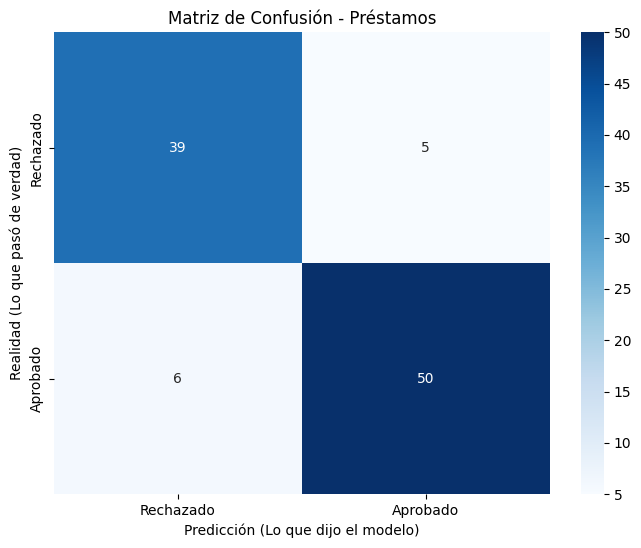

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Realizar predicciones con el set de prueba
y_pred = model.predict(X_test)

# 2. Imprimir métricas de texto
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# 3. Graficar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rechazado', 'Aprobado'],
            yticklabels=['Rechazado', 'Aprobado'])
plt.xlabel('Predicción (Lo que dijo el modelo)')
plt.ylabel('Realidad (Lo que pasó de verdad)')
plt.title('Matriz de Confusión - Préstamos')
plt.savefig('matriz_confusion.png')

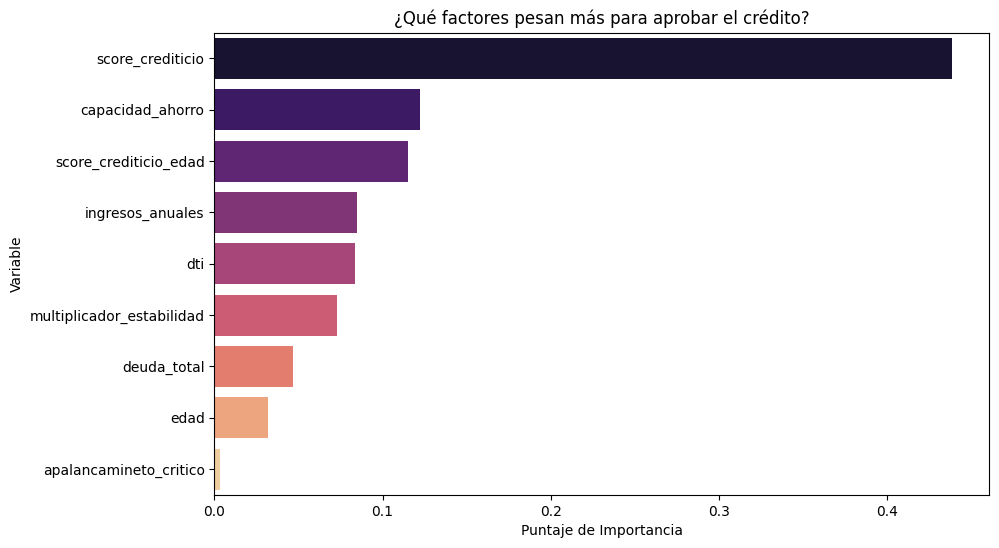

In [3]:


# 1. Obtener la importancia de las variables del modelo entrenado
importancias = model.feature_importances_
nombres_variables = X.columns

# 2. Crear un DataFrame para facilitar el gráfico
df_importancia = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma', hue='Variable')
plt.title('¿Qué factores pesan más para aprobar el crédito?')
plt.xlabel('Puntaje de Importancia')
plt.ylabel('Variable')
plt.show()

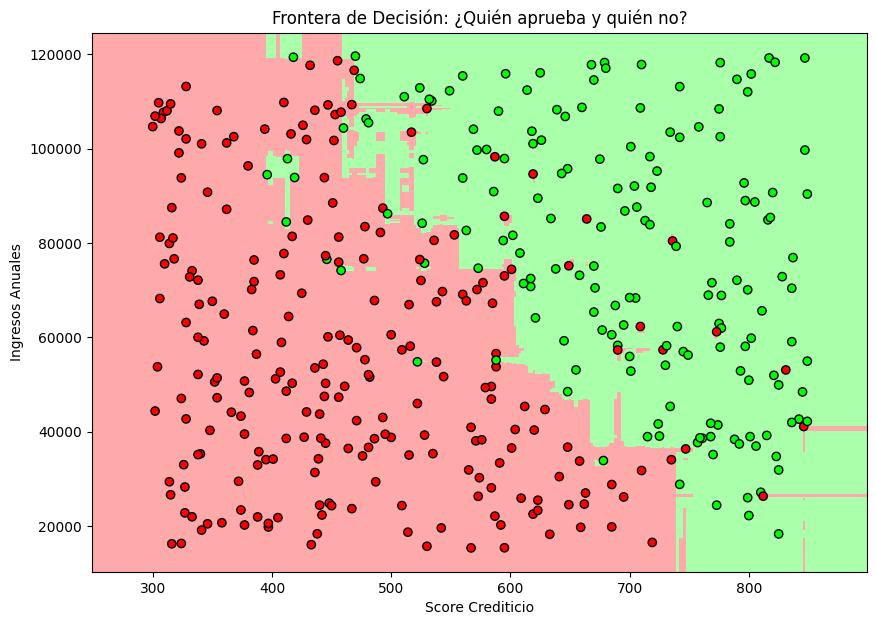

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def graficar_punto_quiebre(X, y, model):
    # X1 = Score Crediticio (Columna 2), X2 = Ingresos Anuales (Columna 1)
    X_vis = X.iloc[:, [2, 1]].values
    y_vis = y.values

    # Entrenamos un modelo solo con esas dos para poder visualizarlo en 2D
    model_2d = RandomForestClassifier(n_estimators=50, random_state=42)
    model_2d.fit(X_vis, y_vis)

    # Crear una malla de puntos para colorear el fondo
    h = 2.0  # tamaño del paso en la malla
    x_min, x_max = X_vis[:, 0].min() - 50, X_vis[:, 0].max() + 50
    y_min, y_max = X_vis[:, 1].min() - 5000, X_vis[:, 1].max() + 5000
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h*50))

    # Predecir sobre la malla
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Graficar
    plt.figure(figsize=(10, 7))
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

    # Graficar también los puntos reales de los clientes
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolors='k', cmap=ListedColormap(['#FF0000', '#00FF00']))
    plt.xlabel('Score Crediticio')
    plt.ylabel('Ingresos Anuales')
    plt.title('Frontera de Decisión: ¿Quién aprueba y quién no?')
    plt.show()

graficar_punto_quiebre(X_train, y_train, model)

In [5]:
joblib.dump(model, 'modelo_prestamos_v2.joblib')

['modelo_prestamos_v2.joblib']